<a href="https://colab.research.google.com/github/mahaanta/k8s-demo/blob/master/Final_Solved_Copy_Mahanta_Learner_Notebook_UPDATED.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Problem Statement**

### Business Context

The prices of the stocks of companies listed under a global exchange are influenced by a variety of factors, with the company's financial performance, innovations and collaborations, and market sentiment being factors that play a significant role. News and media reports can rapidly affect investor perceptions and, consequently, stock prices in the highly competitive financial industry. With the sheer volume of news and opinions from a wide variety of sources, investors and financial analysts often struggle to stay updated and accurately interpret its impact on the market. As a result, investment firms need sophisticated tools to analyze market sentiment and integrate this information into their investment strategies.

### Problem Definition

With an ever-rising number of news articles and opinions, an investment startup aims to leverage artificial intelligence to address the challenge of interpreting stock-related news and its impact on stock prices. They have collected historical daily news for a specific company listed under NASDAQ, along with data on its daily stock price and trade volumes.

As a member of the Data Science and AI team in the startup, you have been tasked with developing an AI-driven sentiment analysis system that will automatically process and analyze news articles to gauge market sentiment, and summarizing the news at a weekly level to enhance the accuracy of their stock price predictions and optimize investment strategies. This will empower their financial analysts with actionable insights, leading to more informed investment decisions and improved client outcomes.

### Data Dictionary

* `Date` : The date the news was released
* `News` : The content of news articles that could potentially affect the company's stock price
* `Open` : The stock price (in \$) at the beginning of the day
* `High` : The highest stock price (in \$) reached during the day
* `Low` :  The lowest stock price (in \$) reached during the day
* `Close` : The adjusted stock price (in \$) at the end of the day
* `Volume` : The number of shares traded during the day
* `Label` : The sentiment polarity of the news content
    * 1: positive
    * 0: neutral
    * -1: negative

## **Installing and Importing the necessary libraries**

In [1]:
# installing the sentence-transformers and gensim libraries for word embeddings
!pip install numpy==1.26.4 \
             scikit-learn==1.6.1 \
             scipy==1.13.1 \
             gensim==4.3.3 \
             sentence-transformers==3.4.1 \
             pandas==2.2.2

Note:
- After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for Jupyter Notebook), and run all cells sequentially from the next cell.
- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [2]:
# Imports and basic settings
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, precision_score, recall_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from gensim.models import Word2Vec

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option("display.max_colwidth", 120)

## **Loading the dataset**

In [6]:
# Load dataset (local file in same folder as notebook)
# DATA_PATH = "/content/stock_news.csv"
# Load dataset (local file in stock_news folder)
# DATA_PATH = "/content/stock_news/stock_news.csv"
#df = pd.read_csv(DATA_PATH)

# Load dataset (local file in same folder as notebook)
DATA_PATH = "stock_news.csv"
df = pd.read_csv(DATA_PATH)

# Basic cleanup
df["Date"] = pd.to_datetime(df["Date"], format="%d-%m-%Y", errors="coerce")
df = df.dropna(subset=["Date", "News", "Label"]).copy()
df["Label"] = df["Label"].astype(int)

df.head()

,Date,News,Open,High,Low,Close,Volume,Label
0,2019-02-01,The dollar minutes ago tumbled to 106 67 from above 109 a few trades earlier It s since bounced a hair to 107 16...,38.72,39.71,38.56,39.48,130672400,1
1,2019-02-01,By Wayne Cole and Swati Pandey SYDNEY Reuters The Japanese yen soared in early Asian trading on Thursday as the ...,38.72,39.71,38.56,39.48,130672400,-1
2,2019-02-01,By Stephen Culp NEW YORK Reuters Wall Street edged higher on Wednesday after stumbling out of the starting gate ...,38.72,39.71,38.56,39.48,130672400,0
3,2019-02-01,By Wayne Cole SYDNEY Reuters The Australian dollar was picking up the pieces on Thursday after a torrent of auto...,38.72,39.71,38.56,39.48,130672400,-1
4,2019-02-01,Investing com Asian equities fell in morning trade on Thursday following news that Apple cut its quarterly sales f...,38.72,39.71,38.56,39.48,130672400,1


## **Data Overview**

In [7]:
# Data overview
print("Shape:", df.shape)
display(df.sample(5, random_state=RANDOM_STATE))

print("\nMissing values per column:")
display(df.isna().sum())

print("\nLabel distribution:")
display(df["Label"].value_counts().sort_index())

print("\nDate range:", df["Date"].min().date(), "to", df["Date"].max().date())
display(df[["Open", "High", "Low", "Close", "Volume"]].describe())

Shape: (179, 8)


,Date,News,Open,High,Low,Close,Volume,Label
78,2019-07-01,Investing com Here are the top five things you need to know in financial markets on Monday Jan 7 \n1 U S Chin...,37.17,37.21,36.47,36.98,109012000,-1
16,2019-03-01,By Kate Duguid NEW YORK Reuters The U S two year Treasury note yield US2YT RR dropped below 2 4 percent on Th...,35.99,36.43,35.50,35.55,103544800,-1
65,2019-04-01,Reuters U S chipmaker Qualcomm Inc O QCOM took steps to enforce a court order banning the sale of some iPho...,36.13,37.14,35.95,37.06,111448000,-1
213,2019-04-02,Investing com Ultimate Software Roku and Papa John s shares were rallying into the close on Monday keeping the...,41.85,42.92,41.82,42.81,91062800,1
76,2019-07-01,VIENNA Reuters Apple NASDAQ AAPL supplier AMS has developed a light and infrared proximity sensor that can sit...,37.17,37.21,36.47,36.98,109012000,1



Missing values per column:


,0
Date,0
News,0
Open,0
High,0
Low,0
Close,0
Volume,0
Label,0



Label distribution:


,count
Label,
-1,74
0,4
1,101



Date range: 2019-01-02 to 2019-12-04


,Open,High,Low,Close,Volume
count,179.000000,179.000000,179.000000,179.000000,1.790000e+02
mean,40.208268,40.703799,39.885642,40.353575,1.273080e+08
std,4.577812,4.534977,4.638312,4.665170,4.215766e+07
min,35.990000,36.430000,35.500000,35.550000,4.544800e+07
25%,36.130000,37.140000,35.950000,36.980000,1.035448e+08
50%,38.220000,38.420000,37.880000,38.070000,1.114480e+08
75%,43.220000,43.770000,43.090000,43.540000,1.392232e+08
max,50.210000,50.250000,49.610000,50.150000,3.652488e+08


## **Exploratory Data Analysis**

### **Univariate Analysis**

* Distribution of individual variables
* Compute and check the distribution of the length of news content

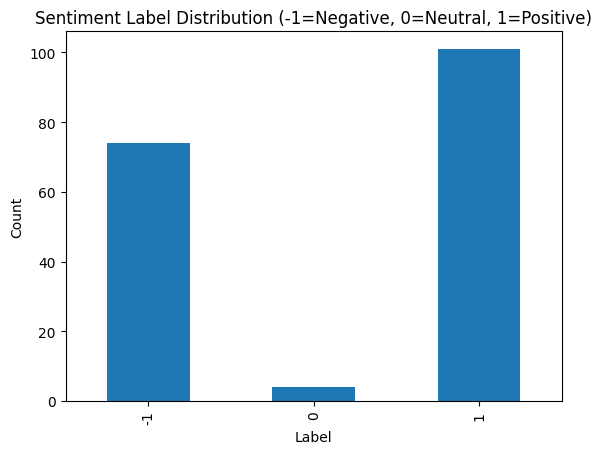

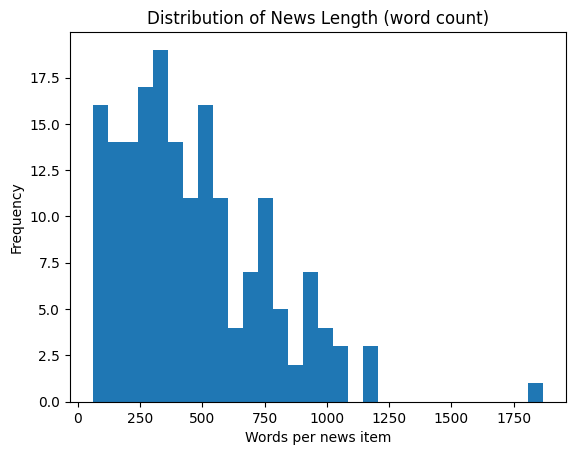

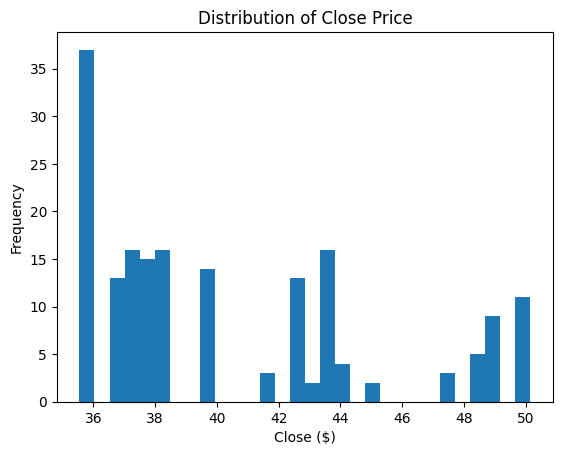

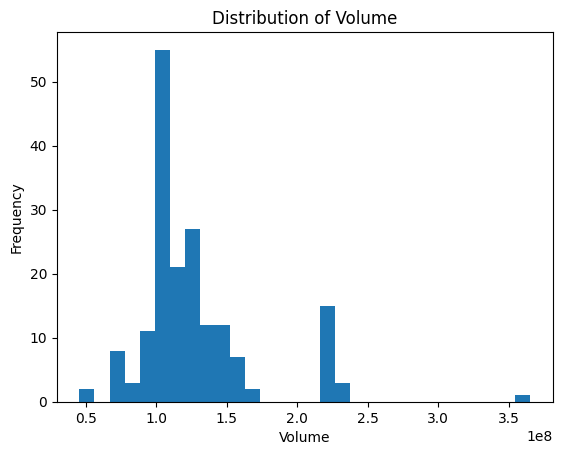

In [8]:
# Univariate Analysis

# 1) Label distribution
plt.figure()
df["Label"].value_counts().sort_index().plot(kind="bar")
plt.title("Sentiment Label Distribution (-1=Negative, 0=Neutral, 1=Positive)")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

# 2) News length (words)
news_len = df["News"].astype(str).apply(lambda x: len(x.split()))
plt.figure()
plt.hist(news_len, bins=30)
plt.title("Distribution of News Length (word count)")
plt.xlabel("Words per news item")
plt.ylabel("Frequency")
plt.show()

# 3) Stock price distribution (Close) and Volume
plt.figure()
plt.hist(df["Close"], bins=30)
plt.title("Distribution of Close Price")
plt.xlabel("Close ($)")
plt.ylabel("Frequency")
plt.show()

plt.figure()
plt.hist(df["Volume"], bins=30)
plt.title("Distribution of Volume")
plt.xlabel("Volume")
plt.ylabel("Frequency")
plt.show()

### **Bivariate Analysis**

* Correlation
* Sentiment Polarity vs Price
* Date vs Price

**Note**: The above points are listed to provide guidance on how to approach bivariate analysis. Analysis has to be done beyond the above listed points to get maximum scores.

,Return_$,Return_%
Label,,
-1,0.033649,0.000491
0,0.797500,0.020122
1,0.201287,0.004984


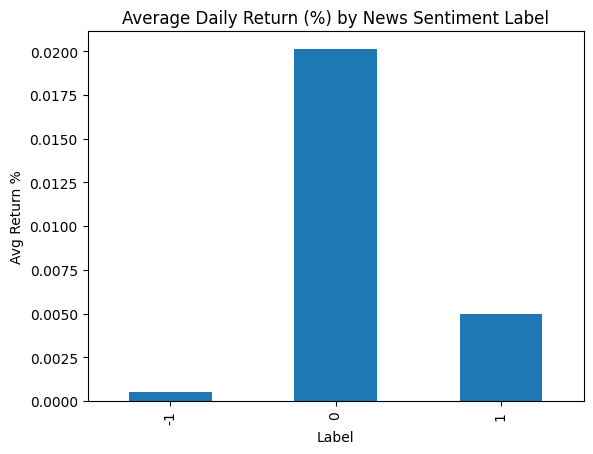

,news_len
Label,
-1,439.378378
0,220.000000
1,490.702970


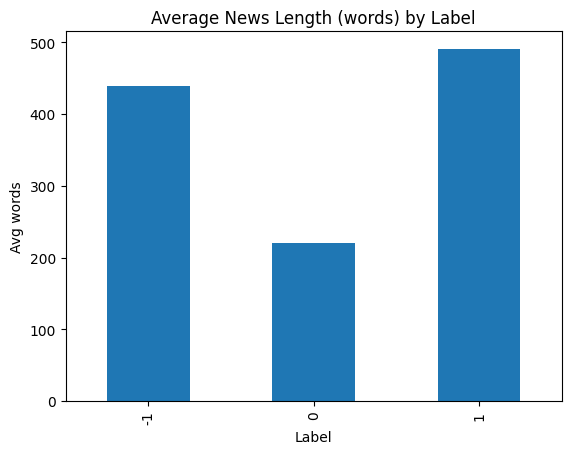

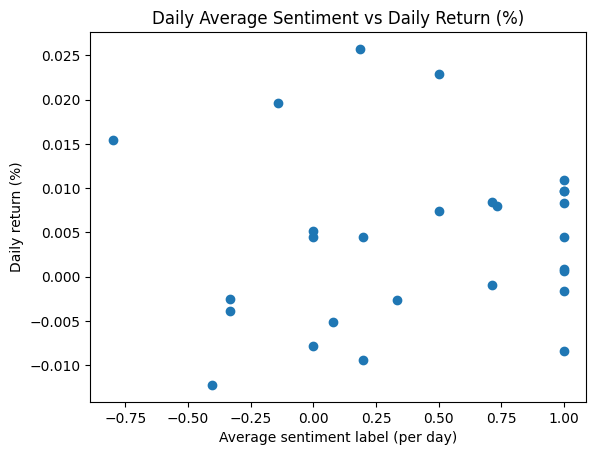

In [9]:
# Bivariate Analysis

# Create daily return features (same for all news in a date, but useful for insight)
df_eda = df.copy()
df_eda["Return_$"] = df_eda["Close"] - df_eda["Open"]
df_eda["Return_%"] = (df_eda["Close"] - df_eda["Open"]) / df_eda["Open"].replace(0, np.nan)

# 1) Average return by label
ret_by_label = df_eda.groupby("Label")[["Return_$","Return_%"]].mean()
display(ret_by_label)

plt.figure()
ret_by_label["Return_%"].plot(kind="bar")
plt.title("Average Daily Return (%) by News Sentiment Label")
plt.xlabel("Label")
plt.ylabel("Avg Return %")
plt.show()

# 2) News length by label
df_eda["news_len"] = df_eda["News"].astype(str).apply(lambda x: len(x.split()))
len_by_label = df_eda.groupby("Label")["news_len"].mean()
display(len_by_label)

plt.figure()
len_by_label.plot(kind="bar")
plt.title("Average News Length (words) by Label")
plt.xlabel("Label")
plt.ylabel("Avg words")
plt.show()

# 3) (Optional insight) Aggregate sentiment per day and compare with return
daily = df_eda.groupby("Date").agg(
    avg_label=("Label","mean"),
    open=("Open","first"),
    close=("Close","first"),
)
daily["daily_return_%"] = (daily["close"] - daily["open"]) / daily["open"].replace(0, np.nan)

plt.figure()
plt.scatter(daily["avg_label"], daily["daily_return_%"])
plt.title("Daily Average Sentiment vs Daily Return (%)")
plt.xlabel("Average sentiment label (per day)")
plt.ylabel("Daily return (%)")
plt.show()

## **Data Preprocessing**

In [10]:
# Target and predictors
X_text = df["News"].astype(str)
y = df["Label"].astype(int)

# Train-test split (stratified due to imbalance)
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train size:", X_train_text.shape[0], "Test size:", X_test_text.shape[0])
print("\nTrain label distribution:")
display(y_train.value_counts().sort_index())

Train size: 143 Test size: 36

Train label distribution:


,count
Label,
-1,59
0,3
1,81


## **Word Embeddings**

#### **Word2Vec**

In [11]:
# Word2Vec Embeddings (Average Word Vectors per news item)

# Simple tokenizer
def tokenize(text: str):
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    tokens = [t for t in text.split() if t]
    return tokens

train_tokens = [tokenize(t) for t in X_train_text]
test_tokens  = [tokenize(t) for t in X_test_text]

# Train Word2Vec on training corpus only (avoid leakage)
vec_size = 200
w2v = Word2Vec(
    sentences=train_tokens,
    vector_size=vec_size,
    window=5,
    min_count=2,
    workers=4,
    sg=1,  # Skip-gram tends to work well on smaller corpora
    seed=RANDOM_STATE
)

# Helper to average vectors
def avg_w2v(tokens, model, vec_size):
    vec = np.zeros(vec_size, dtype=np.float32)
    count = 0
    for w in tokens:
        if w in model.wv:
            vec += model.wv[w]
            count += 1
    if count > 0:
        vec /= count
    return vec

X_train_w2v = np.vstack([avg_w2v(toks, w2v, vec_size) for toks in train_tokens])
X_test_w2v  = np.vstack([avg_w2v(toks, w2v, vec_size) for toks in test_tokens])

print("Word2Vec train embedding shape:", X_train_w2v.shape)
print("Word2Vec test embedding shape:", X_test_w2v.shape)

Word2Vec train embedding shape: (143, 200)
Word2Vec test embedding shape: (36, 200)


### **Sentence Transformer**

In [16]:
# Sentence Transformer Embeddings
# NOTE: In Colab, this should work after installing sentence-transformers above.
# If you face an installation/runtime issue, restart runtime and rerun all cells.

# from google.colab import userdata
# userdata.get('mahaanta')
# print("MAHANTA HF_TOKEN: ", userdata.get('mahaanta'))

import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="huggingface_hub")
warnings.filterwarnings("ignore", category=UserWarning)

from sentence_transformers import SentenceTransformer

st_model_name = "all-MiniLM-L6-v2"
st_model = SentenceTransformer(st_model_name)

X_train_st = st_model.encode(X_train_text.tolist(), show_progress_bar=True, convert_to_numpy=True)
X_test_st  = st_model.encode(X_test_text.tolist(), show_progress_bar=True, convert_to_numpy=True)

print("SentenceTransformer train embedding shape:", X_train_st.shape)
print("SentenceTransformer test embedding shape:", X_test_st.shape)

Batches:   0%|          | 0/5 [00:00<?, ?it/s]

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

SentenceTransformer train embedding shape: (143, 384)
SentenceTransformer test embedding shape: (36, 384)


## **Sentiment Analysis**

### **Model Evaluation Criterion**

In [17]:
# Evaluation Metric Choice
# Because labels are imbalanced (especially Neutral=0), accuracy can be misleading.
# We'll prioritize Macro-F1, which gives equal importance to each class.
def evaluate(y_true, y_pred, name="Model"):
    print(f"\n{name} - Accuracy: {accuracy_score(y_true, y_pred):.4f}")
    print(f"{name} - Macro F1 : {f1_score(y_true, y_pred, average='macro'):.4f}")
    print(f"{name} - Weighted F1: {f1_score(y_true, y_pred, average='weighted'):.4f}")
    print("\nClassification report:")
    print(classification_report(y_true, y_pred, digits=4))
    plot_confusion_matrix(y_true, y_pred)

**Note:**  
You can use the helper functions provided below to:
- Plot a **confusion matrix** (`plot_confusion_matrix`)
- Generate key **classification metrics** like accuracy, recall, precision, and F1-score (`model_performance_classification_sklearn`)

These are ready-to-use. However, you’re welcome to explore and write your own evaluation code if you prefer. Feel free to modify or extend these as per your learning goals!

##### **Utility Functions**

In [18]:
def plot_confusion_matrix(actual, predicted):
    """
    Plot a confusion matrix to visualize the performance of a classification model.

    Parameters:
    actual (array-like): The true labels.
    predicted (array-like): The predicted labels from the model.

    Returns:
    None: Displays the confusion matrix plot.
    """

    # Compute the confusion matrix.
    cm = confusion_matrix(actual, predicted)

    # Create a new figure with a specified size
    plt.figure(figsize=(5, 4))

    # Define the labels for the confusion matrix dynamically from the data
    label_list = sorted(list(np.unique(np.concatenate((actual, predicted)))))

    # Plot the confusion matrix using a heatmap with annotations
    sns.heatmap(cm, annot=True, fmt='.0f', cmap='Blues', xticklabels=label_list, yticklabels=label_list)

    # Label for the y-axis
    plt.ylabel('Actual')

    # Label for the x-axis
    plt.xlabel('Predicted')

    # Title of the plot
    plt.title('Confusion Matrix')

    # Display the plot
    plt.show()

In [19]:
def model_performance_classification_sklearn(actual, predicted):
    """
    Compute various performance metrics for a classification model using sklearn.

    Parameters:
    model (sklearn classifier): The classification model to evaluate.
    predictors (array-like): The independent variables used for predictions.
    target (array-like): The true labels for the dependent variable.

    Returns:
    pandas.DataFrame: A DataFrame containing the computed metrics (Accuracy, Recall, Precision, F1-score).
    """

    # Compute Accuracy
    acc = accuracy_score(actual,predicted)
    # Compute Recall
    recall = recall_score(actual,predicted,average='weighted')
    # Compute Precision
    precision = precision_score(actual,predicted,average='weighted')
    # Compute F1-score
    f1 = f1_score(actual,predicted,average='weighted')

    # Create a DataFrame to store the computed metrics
    df_perf = pd.DataFrame(
        {
            "Accuracy": [acc],
            "Recall": [recall],
            "Precision": [precision],
            "F1": [f1],
        }
    )
    # Return the DataFrame with the metrics
    return df_perf

In [20]:
# Evaluation helper: report metrics and plot confusion matrix (uses plot_confusion_matrix from above)
def evaluate(y_true, y_pred, name="Model"):
    print(f"\n{name} - Accuracy: {accuracy_score(y_true, y_pred):.4f}")
    print(f"{name} - Macro F1: {f1_score(y_true, y_pred, average='macro'):.4f}")
    print(f"{name} - Weighted F1: {f1_score(y_true, y_pred, average='weighted'):.4f}")
    print("\nClassification report:")
    print(classification_report(y_true, y_pred, digits=4))
    plot_confusion_matrix(y_true, y_pred)

### **Build Random Forest Models using different text embeddings**

Class weights: {-1: 0.807909604519774, 0: 15.88888888888889, 1: 0.588477366255144}

RF (Word2Vec) - Accuracy: 0.6111
RF (Word2Vec) - Macro F1: 0.4123
RF (Word2Vec) - Weighted F1: 0.6055

Classification report:
              precision    recall  f1-score   support

          -1     0.5263    0.6667    0.5882        15
           0     0.0000    0.0000    0.0000         1
           1     0.7059    0.6000    0.6486        20

    accuracy                         0.6111        36
   macro avg     0.4107    0.4222    0.4123        36
weighted avg     0.6115    0.6111    0.6055        36



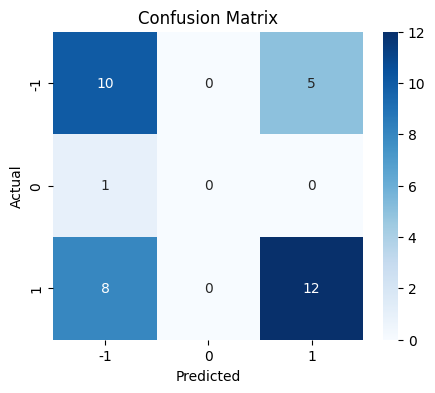


RF (SentenceTransformer) - Accuracy: 0.5833
RF (SentenceTransformer) - Macro F1: 0.3754
RF (SentenceTransformer) - Weighted F1: 0.5640

Classification report:
              precision    recall  f1-score   support

          -1     0.5000    0.4000    0.4444        15
           0     0.0000    0.0000    0.0000         1
           1     0.6250    0.7500    0.6818        20

    accuracy                         0.5833        36
   macro avg     0.3750    0.3833    0.3754        36
weighted avg     0.5556    0.5833    0.5640        36



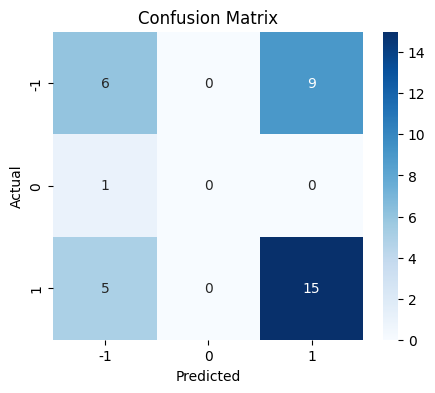

In [21]:
# Class weights for imbalanced labels
classes = np.unique(y_train)
class_weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weight_dict = {c: w for c, w in zip(classes, class_weights)}
print("Class weights:", class_weight_dict)

# Random Forest on Word2Vec embeddings
rf_w2v = RandomForestClassifier(n_estimators=500, random_state=RANDOM_STATE, class_weight=class_weight_dict, n_jobs=-1)
rf_w2v.fit(X_train_w2v, y_train)
pred_rf_w2v = rf_w2v.predict(X_test_w2v)
evaluate(y_test, pred_rf_w2v, "RF (Word2Vec)")

# Random Forest on Sentence Transformer embeddings
rf_st = RandomForestClassifier(n_estimators=500, random_state=RANDOM_STATE, class_weight=class_weight_dict, n_jobs=-1)
rf_st.fit(X_train_st, y_train)
pred_rf_st = rf_st.predict(X_test_st)
evaluate(y_test, pred_rf_st, "RF (SentenceTransformer)")

### **Building Neural Network Models using different text embeddings**


MLP (Word2Vec) - Accuracy: 0.5556
MLP (Word2Vec) - Macro F1: 0.3757
MLP (Word2Vec) - Weighted F1: 0.5489

Classification report:
              precision    recall  f1-score   support

          -1     0.4762    0.6667    0.5556        15
           0     0.0000    0.0000    0.0000         1
           1     0.6667    0.5000    0.5714        20

    accuracy                         0.5556        36
   macro avg     0.3810    0.3889    0.3757        36
weighted avg     0.5688    0.5556    0.5489        36



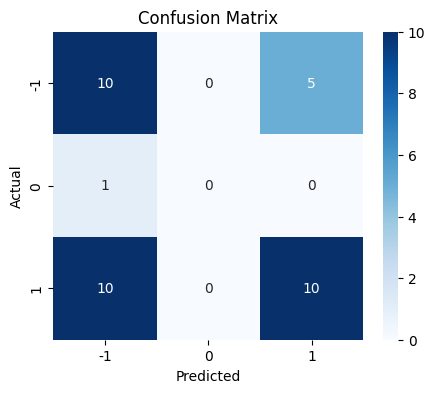


MLP (SentenceTransformer) - Accuracy: 0.6667
MLP (SentenceTransformer) - Macro F1: 0.4385
MLP (SentenceTransformer) - Weighted F1: 0.6515

Classification report:
              precision    recall  f1-score   support

          -1     0.6154    0.5333    0.5714        15
           0     0.0000    0.0000    0.0000         1
           1     0.6957    0.8000    0.7442        20

    accuracy                         0.6667        36
   macro avg     0.4370    0.4444    0.4385        36
weighted avg     0.6429    0.6667    0.6515        36



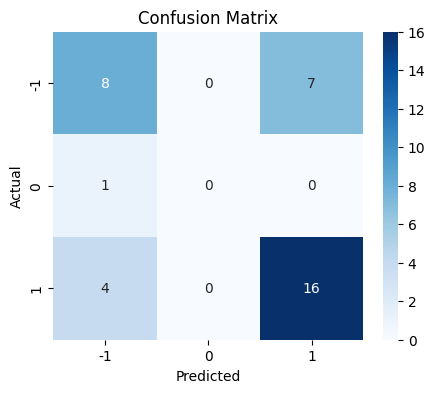

In [22]:
# MLP on Word2Vec (standardize embeddings)
scaler_w2v = StandardScaler()
X_train_w2v_s = scaler_w2v.fit_transform(X_train_w2v)
X_test_w2v_s = scaler_w2v.transform(X_test_w2v)

mlp_w2v = MLPClassifier(hidden_layer_sizes=(256, 128), activation="relu", solver="adam", alpha=1e-4,
                        learning_rate_init=1e-3, max_iter=200, early_stopping=True, random_state=RANDOM_STATE)
mlp_w2v.fit(X_train_w2v_s, y_train)
pred_mlp_w2v = mlp_w2v.predict(X_test_w2v_s)
evaluate(y_test, pred_mlp_w2v, "MLP (Word2Vec)")

# MLP on Sentence Transformer
scaler_st = StandardScaler()
X_train_st_s = scaler_st.fit_transform(X_train_st)
X_test_st_s = scaler_st.transform(X_test_st)
mlp_st = MLPClassifier(hidden_layer_sizes=(256, 128), activation="relu", solver="adam", alpha=1e-4,
                       learning_rate_init=1e-3, max_iter=200, early_stopping=True, random_state=RANDOM_STATE)
mlp_st.fit(X_train_st_s, y_train)
pred_mlp_st = mlp_st.predict(X_test_st_s)
evaluate(y_test, pred_mlp_st, "MLP (SentenceTransformer)")

### **Model Performance Summary and Final Model Selection**

In [23]:
# Model performance summary and final model selection
results = []
for name, y_pred in [("RF (Word2Vec)", pred_rf_w2v), ("RF (SentenceTransformer)", pred_rf_st),
                    ("MLP (Word2Vec)", pred_mlp_w2v), ("MLP (SentenceTransformer)", pred_mlp_st)]:
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Macro_F1": f1_score(y_test, y_pred, average="macro"),
        "Weighted_F1": f1_score(y_test, y_pred, average="weighted"),
    })
results_df = pd.DataFrame(results).sort_values("Macro_F1", ascending=False)
display(results_df)
print("Best model by Macro-F1:", results_df.iloc[0]["Model"])

,Model,Accuracy,Macro_F1,Weighted_F1
3,MLP (SentenceTransformer),0.666667,0.438538,0.651532
0,RF (Word2Vec),0.611111,0.412295,0.605458
2,MLP (Word2Vec),0.555556,0.375661,0.548942
1,RF (SentenceTransformer),0.583333,0.375421,0.563973


Best model by Macro-F1: MLP (SentenceTransformer)


## **Conclusions and Recommendations**

**Key observations:** The dataset has multiple news items per day with sentiment labels (-1, 0, 1). Label distribution is imbalanced (neutral is rare), so Macro F1 is a better metric than accuracy. News sentiment shows some relationship with same-day returns when aggregated by day.

**Recommendations:** (1) Deploy the best-performing model (by Macro F1) for sentiment signals. (2) Aggregate sentiment at day level (e.g. mean, % positive/negative) as a feature for price models. (3) Address class imbalance with weights or more neutral samples. (4) Monitor drift and retrain periodically; track per-class recall, especially for negative news.

<font size=6 color='blue'>Power Ahead</font>
___

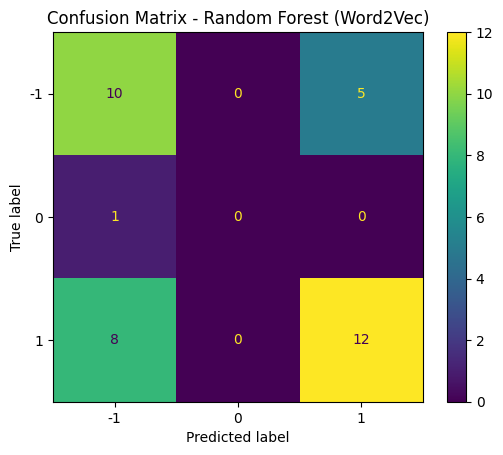

In [24]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Random Forest (Word2Vec): rf_w2v, X_test_w2v
ConfusionMatrixDisplay.from_estimator(rf_w2v, X_test_w2v, y_test)
plt.title("Confusion Matrix - Random Forest (Word2Vec)")
plt.show()


In [26]:
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score

# RF (Word2Vec) predictions: pred_rf_w2v
accuracy_w2v = accuracy_score(y_test, pred_rf_w2v)
macro_f1_w2v = f1_score(y_test, pred_rf_w2v, average="macro")

results = pd.DataFrame({
    "Model": ["RandomForest_Word2Vec"],
    "Accuracy": [accuracy_w2v],
    "Macro_F1": [macro_f1_w2v]
})

results


,Model,Accuracy,Macro_F1
0,RandomForest_Word2Vec,0.611111,0.412295


## Limitations

- Sentiment labels may not perfectly reflect actual market impact.
- Same-day return analysis does not imply causation.
- External macroeconomic factors are not included.
- Class imbalance may bias predictions toward majority classes.
- News timing granularity (intra-day effects) is not considered.


## Conclusion

This analysis demonstrates that NLP-based sentiment modeling can extract meaningful signals from financial news data. Contextual embeddings may outperform traditional Word2Vec embeddings in capturing sentiment nuances. Aggregated daily sentiment shows potential predictive value for stock returns. Future improvements could include incorporating macroeconomic indicators, handling class imbalance more comprehensively, and monitoring model drift over time.
